## **Imports**

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import glob
import cv2
from PIL import Image
import os


## **Files**

**Upload the "test_images.zip" zip file and also the model file "m1.h5" here and then run the code**

In [4]:
!unzip test_images.zip -d /content/

Archive:  test_images.zip
   creating: /content/test_images/
  inflating: /content/test_images/ac985232-00000000.jpg  
  inflating: /content/test_images/ad522266-1f8f3ba4.jpg  
  inflating: /content/test_images/b0e45326-00000000.jpg  
  inflating: /content/test_images/b6579e76-e88b8169.jpg  
  inflating: /content/test_images/b94a9ed0-081117e5.jpg  
  inflating: /content/test_images/c0217f91-3ec34076.jpg  
  inflating: /content/test_images/c45fce16-1139f0fa.jpg  


In [2]:
IMG_H, IMG_W = 256, 256
IMG_SIZE = (IMG_H, IMG_W)

CLASS_COLORS = {
    0: (0,0,0),        # bg
    1: (255,0,0),      # person
    2: (0,255,0),      # car
    3: (0,0,255),      # bus
    4: (0,255,255),    # truck
    5: (255,0,255)     # traffic sign
}

## **Helper Functions**

In [3]:
def preprocess_image(img_path):
    # read image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)

    # EXACT resize used in training
    img = tf.image.resize(img, IMG_SIZE)

    # EXACT normalization used in training (float32 0..1)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # add batch dimension
    img = tf.expand_dims(img, axis=0)

    return img

def colorize_mask(mask2d):
    h,w = mask2d.shape
    out = np.zeros((h,w,3), dtype=np.uint8)
    for cid, col in CLASS_COLORS.items():
        out[mask2d == cid] = col
    return out

def run_inference_display(img_path):
    x = preprocess_image(img_path)
    preds = model.predict(x)

    # obj head
    obj_mask = np.argmax(preds["obj_mask"][0], axis=-1)
    obj_color = colorize_mask(obj_mask)

    # lane head (threshold at 0 → logits)
    lane_mask = (preds["lane_mask"][0, ..., 0] > 0.0).astype(np.uint8)

    # load original for display (unnormalized)
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_W, IMG_H))

    # -------- DISPLAY RESULT --------
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(orig); plt.title("Input"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(obj_color); plt.title("Predicted Objects"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(lane_mask, cmap='gray'); plt.title("Predicted Lane"); plt.axis('off')
    plt.show()


## **Load Model and Run**

In [6]:
model = tf.keras.models.load_model("/content/m1.h5", compile=False)

Total Test Images Found: 7
Running: /content/test_images/ac985232-00000000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


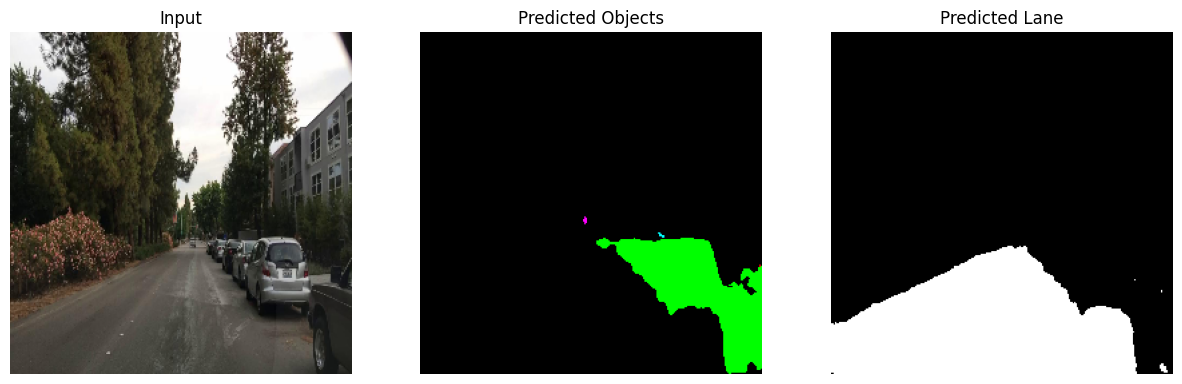

Running: /content/test_images/ad522266-1f8f3ba4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


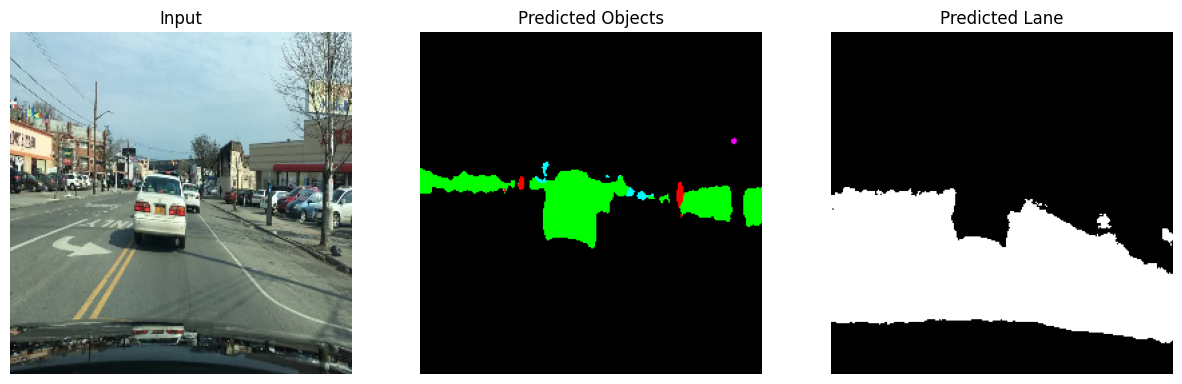

Running: /content/test_images/b0e45326-00000000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


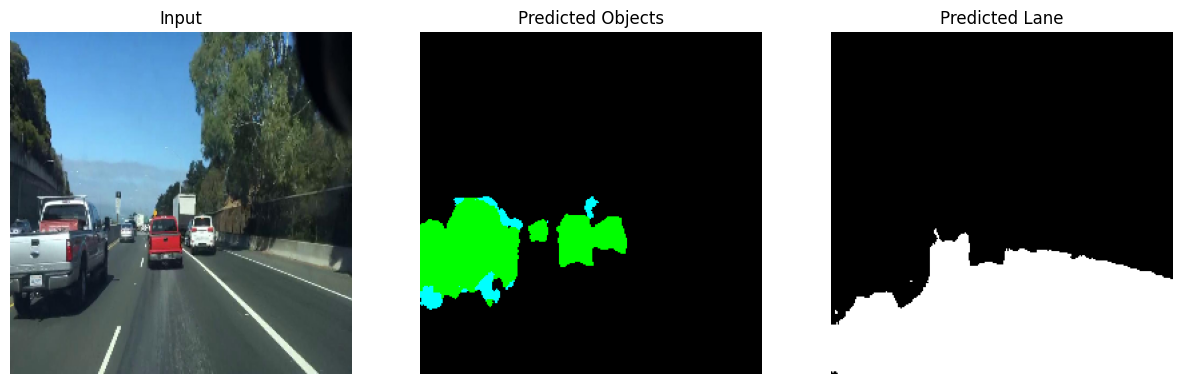

Running: /content/test_images/b6579e76-e88b8169.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


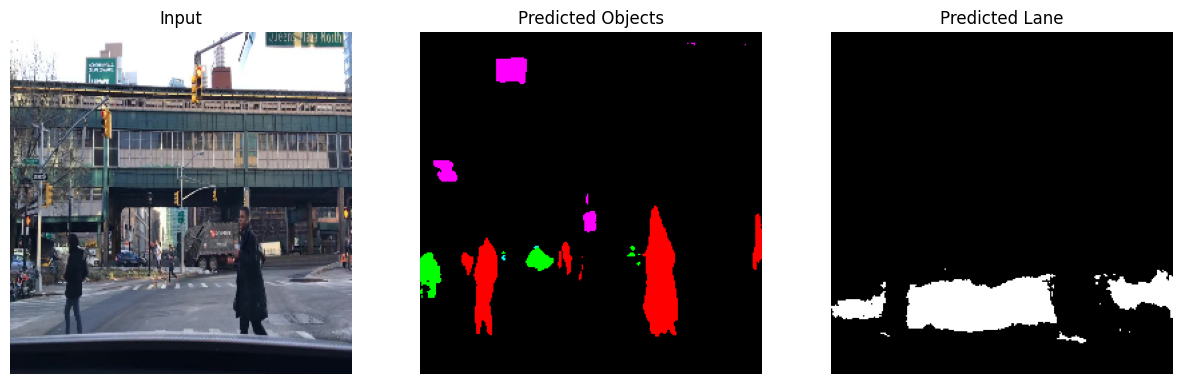

Running: /content/test_images/b94a9ed0-081117e5.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


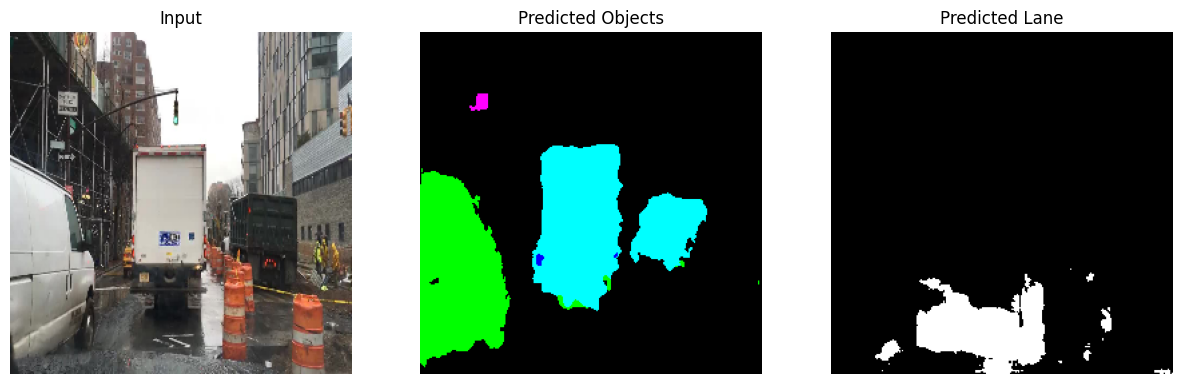

Running: /content/test_images/c0217f91-3ec34076.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


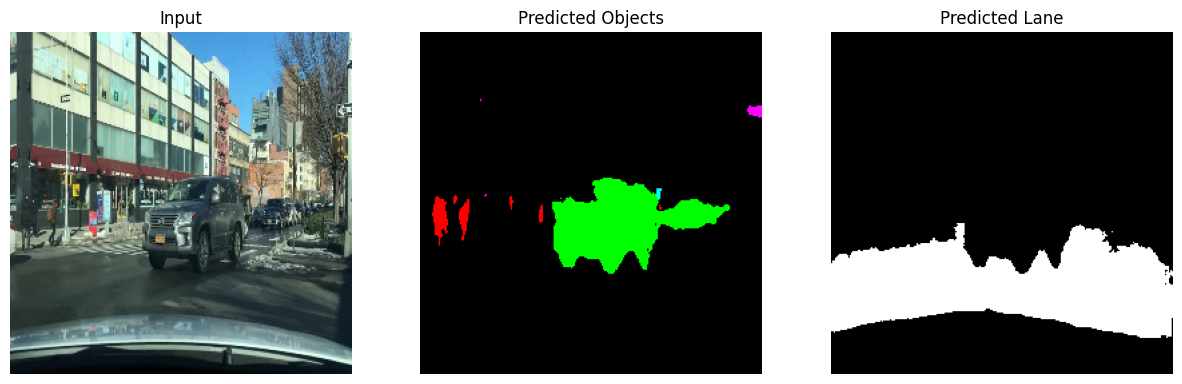

Running: /content/test_images/c45fce16-1139f0fa.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


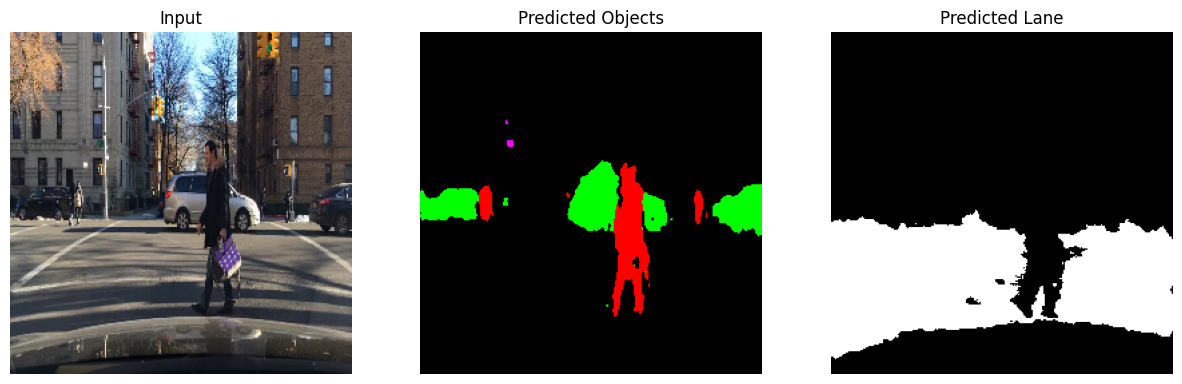

In [7]:
TEST_DIR = "/content/test_images"  # after unzip

all_images = sorted([
    os.path.join(TEST_DIR, f)
    for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Total Test Images Found:", len(all_images))

for img_path in all_images:
    print("Running:", img_path)
    run_inference_display(img_path)